<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/17_4_3_THEORY_Implementing_a_GPT_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

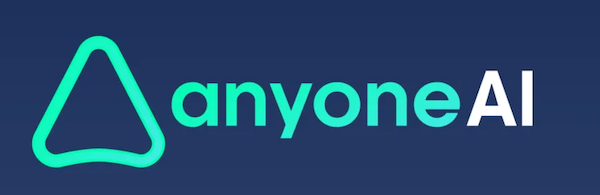

# GPT Implementation from Scratch

In this notebook, we will walk through the process of implementing a GPT (Generative Pretrained Transformer) model such as GPT-3 from scratch. The objective is to understand the key components of GPT architecture and how it can be trained on a simple dataset. We'll cover the following steps:

1. **Dataset Preparation:** We will use a small toy dataset to simplify the training process. The dataset consists of simple sentences, and we will tokenize them into sequences to create input-output pairs for training the model.
   
2. **Model Architecture:** We will implement the core components of the GPT model, including embedding layers, multi-head attention, and the transformer architecture.

3. **Training the Model:** The model will be trained to predict the next word in a sequence, using a sequence of words as input and generating probabilities for the next word.

By the end of this notebook, you will have a clear understanding of the fundamentals behind GPT models and how to build one using TensorFlow and Keras.

Let's begin!



### Importing Libraries

We start by importing the necessary libraries and modules for building the GPT model:

- **TensorFlow:** The core deep learning library used to build and train neural networks.
- **Keras Layers:**
  - **Embedding:** Converts word indices into dense vectors of fixed size, serving as the first layer of the model.
  - **Dense:** Fully connected layers used for the final output.
  - **LayerNormalization:** Normalizes the input across the features dimension to improve training stability.
  - **Dropout:** Randomly sets a fraction of input units to zero during training to prevent overfitting.
- **NumPy:** A library for numerical computations, primarily used to handle arrays and matrices, especially when preparing the input and output sequences.

As you can see, we'll only use some core packages!

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Dense, LayerNormalization, Dropout
from tensorflow.keras.models import Model
import numpy as np

### Dataset and Tokenization

To simplify the training process, we use a small toy dataset consisting of four short sentences. These sentences provide us with a minimalistic context to train our GPT model while still demonstrating its functionality.

To prepare the dataset for the model training, we should tokenize the data, prepare the sequences for training, and generate a dataset padding the sequences:

1. **Tokenization:**
   We tokenize the sentences into sequences of integer indices, where each word in the dataset is mapped to a unique integer. This mapping creates a vocabulary that the model will learn during training.

2. **Input-Output Pairs:**
   For training the model, we generate input-output pairs from the tokenized data. Each input is a partial sequence of a sentence, and the output is the next word in that sequence. This allows the model to learn how to predict the next word given the previous ones.

3. **Padding Sequences:**
   To ensure that all input sequences are of the same length, we pad the sequences to match the longest one in the dataset. Padding is essential for batch processing in neural networks.

By preparing the dataset in this manner, we can effectively train our GPT model on a structured set of input-output pairs, teaching it to predict the next word based on a given context.

In [ ]:
# Create the data

### To make the training process simpler, we'll create a small toy dataset
data = [
    'This was a horrible movie',
    'This is a nice one',
    'The acting was amazing',
    'The actors were good'
]

In [ ]:
# Tokenize the data

### We'll use the Tokenizer from Keras as an example.
### There are multiple ways to generate the tokens.
### You can use the package tiktoken from Open AI to explore the tokenization used for GPT models
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(data)

# Set the vocabulary of the model as the word_index + padding token
vocab_size = len(tokenizer.word_index) + 1

# Conver the text to sequences of tokens
sequences = tokenizer.texts_to_sequences(data)

In [ ]:
sequences

[[1, 2, 3, 5, 6], [1, 7, 3, 8, 9], [4, 10, 2, 11], [4, 12, 13, 14]]

In [ ]:
# Create input-output pairs
input_sequences = []
output_words = []

for seq in sequences:
    # In each sentence the input-output pairs are generated predicting the next token
    for i in range(1, len(seq)):
        # All previous tokens:
        input_sequences.append(seq[:i])
        # Next token:
        output_words.append(seq[i])

# Show some samples
for i in range(6):
    print(f"Input: {input_sequences[i]}, Output: {output_words[i]}")

Input: [1], Output: 2
Input: [1, 2], Output: 3
Input: [1, 2, 3], Output: 5
Input: [1, 2, 3, 5], Output: 6
Input: [1], Output: 7
Input: [1, 7], Output: 3


In [ ]:
input_sequences.shape

(14, 4)

In [ ]:
# Pad sequences
### Get the longest sequence
max_sequence_length = max(len(seq) for seq in input_sequences)
### Pad the sequences with 0s
input_sequences = tf.keras.preprocessing.sequence.pad_sequences(input_sequences, maxlen=max_sequence_length, padding='post')
output_words = np.array(output_words)

for i in range(6):
    print(f"Input: {input_sequences[i]}, Output: {output_words[i]}")

Input: [1 0 0 0], Output: 2
Input: [1 2 0 0], Output: 3
Input: [1 2 3 0], Output: 5
Input: [1 2 3 5], Output: 6
Input: [1 0 0 0], Output: 7
Input: [1 7 0 0], Output: 3


# Model

We'll create a GPT-like model in tensorflow using the decoder architecture from the paper [Attention is all you need](https://arxiv.org/pdf/1706.03762).

The same architecture used in the GPT models!!

So our goal is to have something like this:

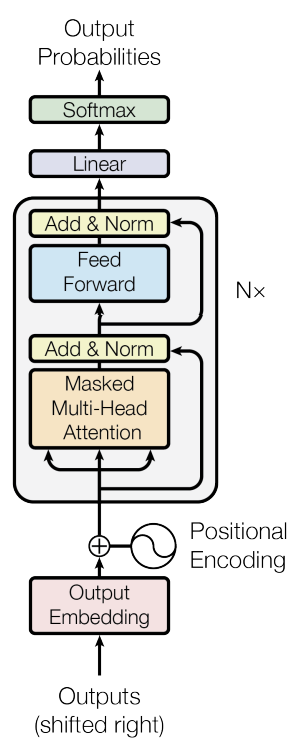

## Transformer Block

The key part of the transformer architecture is the transformer block composed mainly of the Scaled dot product module and the Multi-head attention module. Let's create those in tensorflow!

### Scaled dot product attention:
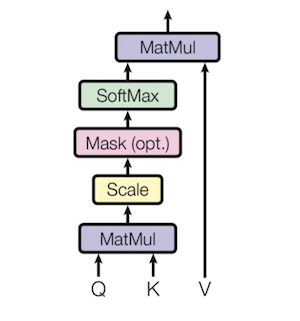

The attention mechanism is defined by the following formula:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d}}\right) V
$$

Where:
- $ Q, K$, and $V $ represent the query, key, and value matrices.
- $ K $ represents the key matrix.
- $ d $ is the dimension of the key vectors.

This formula computes the dot-product attention, which is a key component of transformer models.


In [ ]:
class ScaledDotProductAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(ScaledDotProductAttention, self).__init__(**kwargs)

    def call(self, query, key, value, mask=None, causal=True):
        # The equation is:
        # attention(Q, K, V) = softmax(QK^T / sqrt(d_k))V

        # Q.K^T
        matmul_qk = tf.matmul(query, key, transpose_b=True)

        # Scale it
        # QK^T / sqrt(d_k)
        dk = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        # Add the mask to the scaled tensor if mask.
        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        if causal:
            # Create a causal mask by determining the size of the sequence
            seq_len = tf.shape(query)[-2]
            causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

            # Apply the causal mask (set logits for future tokens to a very large negative number)
            scaled_attention_logits += (causal_mask - 1.0) * 1e9

        # softmax(QK^T / sqrt(d_k))
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

        # attention(Q, K, V) = softmax(QK^T / sqrt(d_k))V
        output = tf.matmul(attention_weights, value)

        return output, attention_weights

### Multi-head attention

The following class will create the Multi-head Attention module. To do so we'll use the previous Scaled Dot-product attention

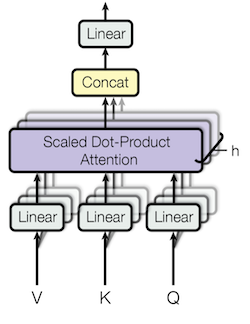

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)

        # Number of heads
        self.num_heads = num_heads
        # Dimension of the linear projection of the embeddings
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        # Dimension of the depth of each head
        self.depth = d_model // self.num_heads

        # Linear projections for Q, K, V
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

        # Linear projection for the output
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        # Initial shape (Batch, Sequence, Embedding)
        # Resulting dimension (Batch, Sequence, num_heads, depth)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        # Transpose to (Batch, num_heads, Sequence, depth)
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask):
        # Batch size
        batch_size = tf.shape(q)[0]

        # Generate the linear projection of Q, K, V
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        # Split the heads
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Apply the Scaled Dot Product Attention to the projected Q, K, and V heads
        scaled_attention, _ = ScaledDotProductAttention()(q, k, v, mask)

        # Transpose to (Batch, Sequence, num_heads, depth)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

        # Concatenate the heads
        # Resulting shape (Batch, Sequence, d_model)
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

        # Apply the final linear projection
        output = self.dense(concat_attention)

        return output


### Transformer Block

Once we have the Multi-head Attention, we can actually create the transformer block that is the base od our transformer architecture


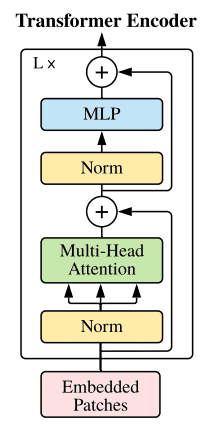

In [ ]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)

        # Multi-head Attention block with a projection embedding size d_model, and num_heads heads
        self.mha = MultiHeadAttention(d_model, num_heads)

        # MLP:
        # First dense layer with dff units and ReLU activation
        # Second dense layer with d_model units
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])

        # Normalization layers
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        # Dropout (optional)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask):
        # Multi-head Attention
        attn_output = self.mha(x, x, x, mask)
        # Apply dropout
        attn_output = self.dropout1(attn_output, training=training)
        # Add the attention output to the input
        # X + Attention output
        out1 = self.layernorm1(x + attn_output)

        # Feed-forward network (MLP)
        ffn_output = self.ffn(out1)
        # Apply dropout
        ffn_output = self.dropout2(ffn_output, training=training)

        # Add the MLP output to the attention output
        # X + Attention output + MLP output
        out2 = self.layernorm2(out1 + ffn_output)

        return out2


### GPT Like model architecture

Finally, we'll create a GPT like model architecture. This architecture is basically a decoder transformer model:

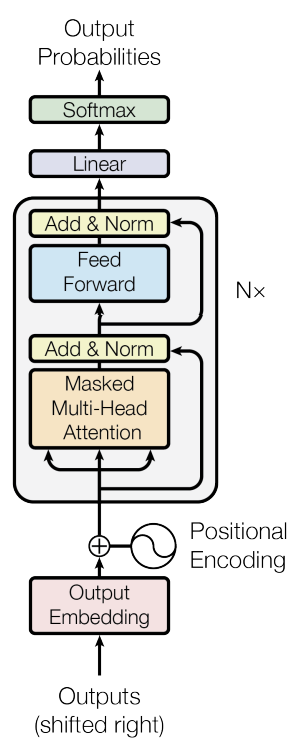

In [ ]:
class GPT(Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, rate=0.1):
        super(GPT, self).__init__()

        # Embedding layer to convert input tokens to vector embeddings
        self.embedding = Embedding(input_vocab_size, d_model)

        # Positional encoding layer to add positional information to the embeddings
        self.pos_encoding = self.positional_encoding(maximum_position_encoding, d_model)

        # Transformer blocks
        # Each transformer block consists of a multi-head attention layer and a point-wise feed-forward network
        # The output of each transformer block is fed into the next transformer block
        # This process is repeated num_layers times:
        self.dec_layers = [TransformerBlock(d_model, num_heads, dff, rate) for _ in range(num_layers)]

        # Dropout layer to reduce overfitting
        # Dropout is applied to the output of the last transformer block
        self.dropout = Dropout(rate)

        # Final dense layer to convert the output of the last transformer block to the output vocabulary
        self.final_layer = Dense(input_vocab_size)

    def positional_encoding(self, position, d_model):
        # Create a matrix of angles
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis], np.arange(d_model)[np.newaxis, :], d_model)
        # Apply sine and cosine to the angles
        # Even values are assigned to sin
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        # Odd values are asigned to cos
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]

        return tf.cast(pos_encoding, dtype=tf.float32)

    def get_angles(self, pos, i, d_model):
        # The angles are defined by the equation
        # pos = position
        # i = depth
        # d_model = model dimension
        # angle = pos / 10000^(2(i)/d_model)
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    def create_padding_mask(self, seq):
        # Create a mask to ignore padding tokens
        # Padding tokens are represented by 0 in the input sequence
        seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
        return seq[:, tf.newaxis, tf.newaxis, :]

    def call(self, x, training):
        # Sequence length (Number of tokens)
        seq_len = tf.shape(x)[1]
        # Create a mask to ignore padding tokens
        attention_mask = self.create_padding_mask(x)

        # Embedding and positional encoding
        x = self.embedding(x)
        # Add positional encoding to the embeddings
        x += self.pos_encoding[:, :seq_len, :]

        # Dropout
        x = self.dropout(x, training=training)

        # Transformer blocks
        # This process is repeated num_layers times:
        for i in range(len(self.dec_layers)):
            x = self.dec_layers[i](x, training=training, mask=attention_mask)

        # Final dense layer
        x = self.final_layer(x)

        # Return the output
        # We'll select the last time step's output as the output of the model
        return x[:, -1, :]


### Create an instance of the model

In [ ]:
# Hyperparameters
# Number of transformer layers
num_layers = 2
# Embedding dimension
d_model = 128
# Number of attention heads
num_heads = 4
# Feed-forward network dimension
dff = 512
# Input vocabulary size
maximum_position_encoding = max_sequence_length
# Dropout rate
dropout_rate = 0.1

# Create an instance of the model
gpt = GPT(num_layers, d_model, num_heads, dff, vocab_size, maximum_position_encoding, rate=dropout_rate)

# Compile the model
# We'll use the Adam optimizer and the SparseCategoricalCrossentropy loss function
gpt.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

# Train the model
gpt.fit(input_sequences, output_words, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 3.9782
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 3.7571
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 3.1196
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 2.7361
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 2.7914
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 2.6013
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 2.6707
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 2.8208
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2.5235
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 2.3618


In [ ]:
gpt.summary()

Model: "gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4, 128)         │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ ?                      │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4, 15)          │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,201,199 (4.58 MB)

 Trainable params: 400,399 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 800,800 (3.05 MB)

In [ ]:
def generate_text(model, tokenizer, prompt, max_length):
    for _ in range(max_length):
        # Tokenize the prompt
        tokenized_prompt = tokenizer.texts_to_sequences([prompt])
        # Pad the prompt
        padded_prompt = tf.keras.preprocessing.sequence.pad_sequences(tokenized_prompt, maxlen=max_sequence_length, padding='post')
        # Predict the next word
        predictions = model.predict(padded_prompt)
        # Get the predicted word
        predicted_id = tf.argmax(predictions[0]).numpy()
        if predicted_id == 0:
            break
        # Convert the predicted word to text
        predicted_word = tokenizer.index_word[predicted_id]
        # Add the predicted word to the prompt
        prompt += " " + predicted_word
    return prompt

prompt = "Hi"
generated_text = generate_text(gpt, tokenizer, prompt, max_length=20)
print(generated_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Hi was was was was a was a was a was a was a was a was a was a was


### Note:

Of course, training such a big and complex model on a small dataset like this one with only 4 words will result in overfitting. Large language models require huge amounts of data and computation to be trained. Next lecture we'll see how we can simply import a pre-trained model and use it!